<a href="https://colab.research.google.com/github/manugiraldo123/Integracion-de-datos-y-prospectiva/blob/main/1_Integraci%C3%B3n_Datos_Muestreo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Caso de estudio - primer método de integración**

El primer método de integración de datos se conoce como el método de muestreo (muestreo por cluusterización - Montecarlo) . Este método está determinado por el indice de confiabilidad. De manera general, la confiabilidad a norma internacional está marcado por una confiabilidad del 99.9%, lo que requeriría como mínimo un totald de 1000 datos.

0. Cargamos la librerías de trabajo

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Cargamos los datos de trabajo

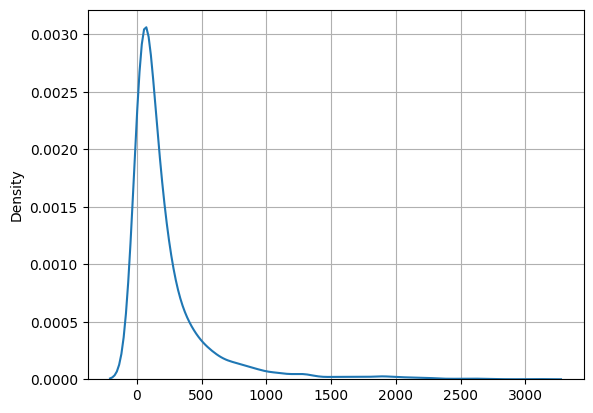

In [10]:
nxl = "/content/drive/MyDrive/Integración de datos/1. RiesgoOperacional_EVERGREEEN.xlsx"
XDB = pd.read_excel(nxl, sheet_name=0)
#display(XDB)
Freq = XDB.iloc[:,3]; Sev = XDB.iloc[:,4]
LDA = Freq*Sev

plt.figure()
sns.kdeplot(LDA)
plt.grid()
plt.show()

2. Se procede con la creación de los concentradores de información (clusters)

In [18]:
import random
random.seed(42)
XC = np.array(random.choices(LDA, k = 5))   #selecciona 5 valores de manera aleatoria.

#Organizar los datos de menor a mayor
XC = np.sort(XC)
print("Los concentradores de información son:" , XC)

Los concentradores de información son: [ 66.68668397  83.48720974  85.08350368 192.09214682 203.24462183]


3. se clasifican los datos de acuerdo con los concentradores de información

In [40]:
box0=[]; box1=[]; box2=[] ; box3=[] ; box4=[]
Boxes = [box0, box1, box2, box3, box4]


for k in range(len(LDA)):

  d= np.abs(XC - LDA.iloc[k,])/XC  #La distancia de un dato a un concentrador
  nc = np.argmin(d)   #Indica el numero de la caja donde voy a introducir el dato
  #print("Las distancias porcentuales son", d)
  #print("El dato pertenece a la categoría" , nc)
  Boxes[nc].append(LDA.iloc[k,])

#Determinamos el porcentaje de datos por caja
pm=[]  #Vector de porcentajes
for j in range(5):
  pd = len(Boxes[j])/len(LDA)
  pm.append(pd)

pm = (np.array(pm)*1000).astype(int)
print("El porcentaje de datos por caja es", pm)



El porcentaje de datos por caja es [379  37  93 156 333]


4. sacamos datos por caja y creamos una LDA2 (con mil datos)


<function matplotlib.pyplot.show(close=None, block=None)>

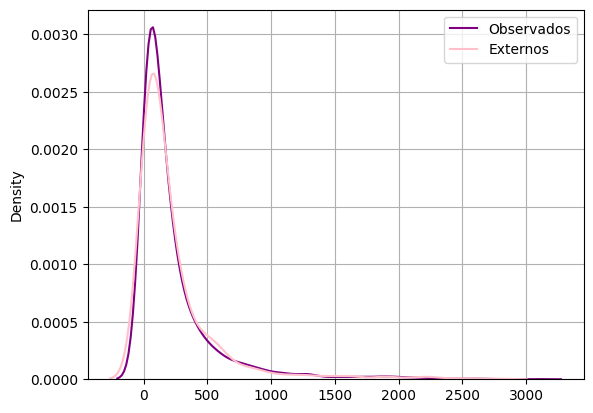

In [52]:
LDA2 = []   #Aqui van a quedar los 1000 datos


for j in range(5):
  LDA2.extend(random.choices(Boxes[j], k=pm[j]))

LDA2 = np.array(LDA2)


#Se comprueban las métricas estadisticas
uo= np.mean(LDA)
print("La media de los datos observados es", uo)

ue = np.mean(LDA2)
print("La media de los datos externos es", ue)

du = np.abs(uo - ue)/uo
print("el error relativo porcentual es", du*100)

#Idealmente se pone la gráfica de ambas distribuciones
plt.figure()
sns.kdeplot(LDA, label = "Observados", color='purple')
sns.kdeplot(LDA2, label = "Externos", color = 'pink')
plt.grid()
plt.legend()
plt.show


**Análisis de resultados**
De acuerdo con el método de integración de datos por muestreo aleatorio y concentradores de información, la discrepancia que se obtuvo para la media de las distribuciones (datos observados: LDA , y datos externos: LDA2) estuvo por debajo del 5%, lo que indica que el 95% de los datos aproximadamente fueron correctamente seleccionados.
Este proceso de muestreo se hizo con el fin de lograr una confiabilidad del 99,9% de las pérdidas por dejar contenedores en tierra.